In [18]:
import pandas as pd
import numpy as np
 
data=pd.read_csv('异常检测数据集.csv')
data=data.drop(['label'],axis=1)
data.head()

,x,y
0,10.411159,9.540142
1,9.533619,9.656688
2,9.802205,8.622943
3,9.721842,10.783296
4,11.474122,10.479565


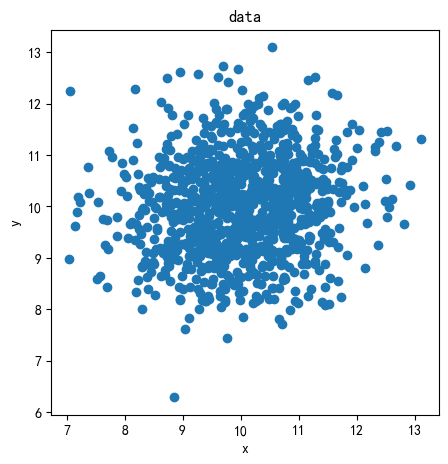

In [19]:
%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure(figsize=(5,5))
plt.scatter(data.loc[:,'x'],data.loc[:,'y'])
plt.title('data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [20]:
x=data.loc[:,'x']
y=data.loc[:,'y']

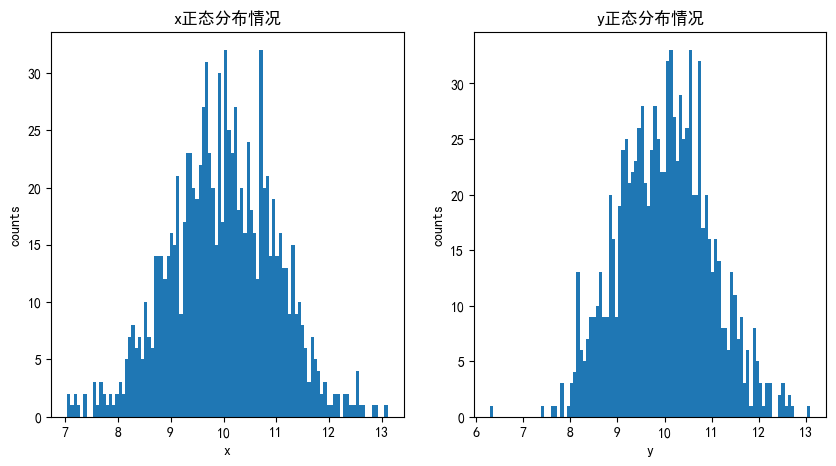

In [21]:
fig2=plt.figure(figsize=(10,5))
plt.subplot(121)
plt.hist(x,bins=100)
plt.title('x正态分布情况')
plt.xlabel('x')
plt.ylabel('counts')
plt.subplot(122)
plt.hist(y,bins=100)
plt.title('y正态分布情况')
plt.xlabel('y')
plt.ylabel('counts')
plt.show()

In [24]:
x_mean=x.mean()
x_sigma=x.std()
y_mean=y.mean()
y_sigma=y.std()
print(x_mean,x_sigma,y_mean,y_sigma)

9.98549360118094 0.9967554041218933 10.008681287562665 0.9627546264100806


In [28]:
from scipy.stats import norm
range1=np.linspace(0,20,300)
x_normal=norm.pdf(range1,x_mean,x_sigma)
y_normal=norm.pdf(range1,y_mean,y_sigma)

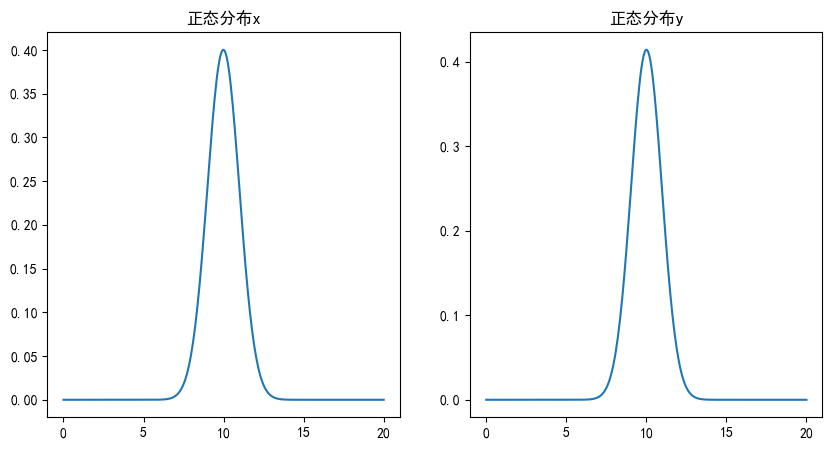

In [30]:
fig3=plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(range1,x_normal)
plt.title('正态分布x')

plt.subplot(122)
plt.plot(range1,y_normal)
plt.title('正态分布y')

plt.show()

In [33]:
from sklearn.covariance import EllipticEnvelope
ad_model=EllipticEnvelope()
ad_model.fit(data)

,store_precision,True
,assume_centered,False
,support_fraction,None
,contamination,0.1
,random_state,None


In [37]:
y_predict=ad_model.predict(data)
print(pd.Series(y_predict).value_counts())

 1    900
-1    100
Name: count, dtype: int64


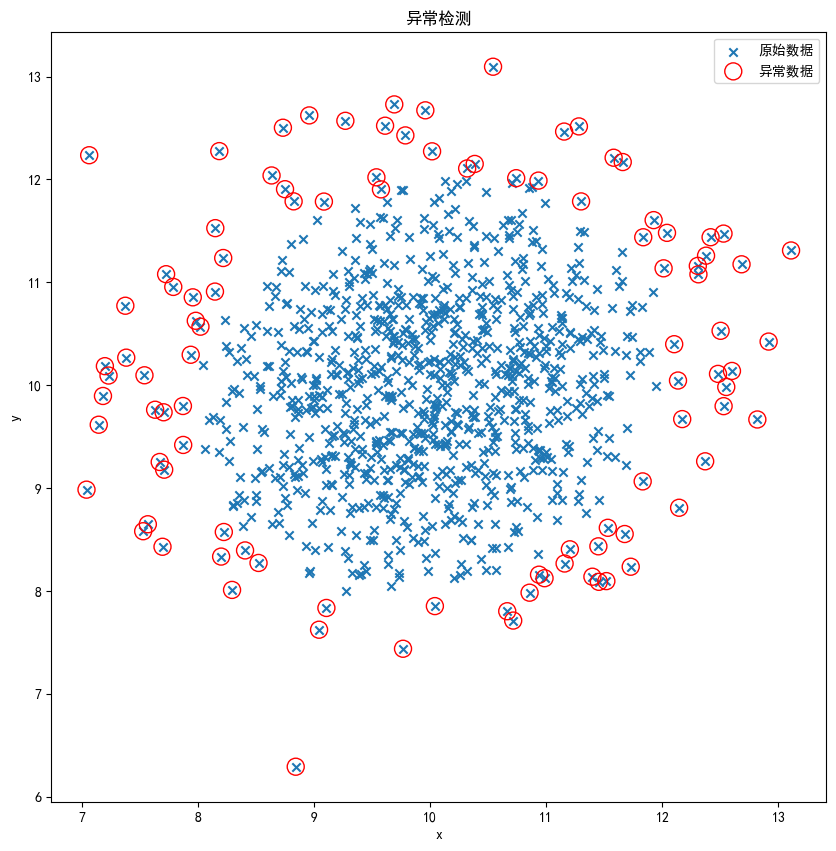

In [44]:
fig4=plt.figure(figsize=(10,10))
orginal_data=plt.scatter(data.loc[:,'x'],data.loc[:,'y'],marker='x')
anomaly_data=plt.scatter(data.loc[:,'x'][y_predict==-1],data.loc[:,'y'][y_predict==-1],marker='o',facecolor='none',edgecolors='red',s=150)
plt.title('异常检测')
plt.xlabel('x')
plt.ylabel('y')
plt.legend((orginal_data,anomaly_data),('原始数据','异常数据'))
plt.show()

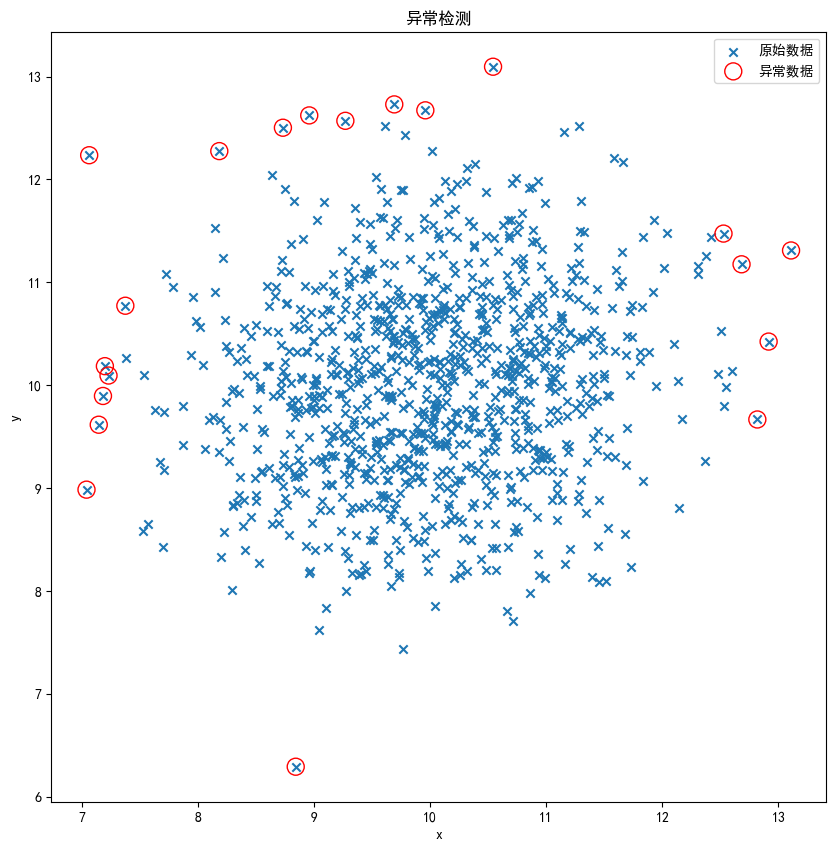

In [45]:
ad_model=EllipticEnvelope(contamination=0.02)
ad_model.fit(data)
y_predict=ad_model.predict(data)
fig5=plt.figure(figsize=(10,10))
orginal_data=plt.scatter(data.loc[:,'x'],data.loc[:,'y'],marker='x')
anomaly_data=plt.scatter(data.loc[:,'x'][y_predict==-1],data.loc[:,'y'][y_predict==-1],marker='o',facecolor='none',edgecolors='red',s=150)
plt.title('异常检测')
plt.xlabel('x')
plt.ylabel('y')
plt.legend((orginal_data,anomaly_data),('原始数据','异常数据'))
plt.show()